In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray
from sklearn.linear_model import TheilSenRegressor
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
import statsmodels.api as sm



from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from rasterio import features
from affine import Affine
import geopandas as gp

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl2025/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
cpc_dir =  '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'


In [3]:
#conversion factors
cm_to_mm = 10
scale = 0.1

In [4]:
pexq_df = pd.read_csv(save_dir + 'pexq_df.csv')


In [5]:
# helper functions for plotting

def detrend_dim(da, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim='water_year', deg=deg)
    fit = xr.polyval(da.water_year, p.polyfit_coefficients)
    return da - fit

def flipLon360(ds):
    # convert -180-180 to 0-360
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

def fixLonLine(ds):
    # wrap lon to fix nans meridian for mapping
    # find the index of the last column before lon=0
    last_valid_lon_index = ds.lon.argmax().item()  

    # fill the NaNs in the last column with the values from the adjacent column
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index -1].where(np.isnan(ds[:, last_valid_lon_index]), ds[:, last_valid_lon_index])

    return ds

def fixLonLine0(ds):
    # another wrap lon to fix nans meridian for mapping
    last_valid_lon_index = ds.lon.argmax().item()  
    # fill the NaNs in the last column with the values from the adjacent column
    ds[:, 0] = ds[:, last_valid_lon_index -1].where(np.isnan(ds[:, last_valid_lon_index]), ds[:, last_valid_lon_index])

    return ds

def fixLonLine2(ds):
    # yet another wrap lon to fix nans meridian for mapping
    # Ensure there are valid lon values to process
    if ds.lon.size == 0 or np.isnan(ds.lon).all():
        raise ValueError("Longitude array is empty or all values are NaN.")

    # Find the index of the last valid column before lon=0
    valid_lons = ds.lon.values
    last_valid_lon_index = np.nanargmax(valid_lons) - 1  # One before the last

    # Ensure last_valid_lon_index is valid
    if last_valid_lon_index < 0:
        raise ValueError("No valid longitude values before 0.")

    # Fill the NaNs in the last column with the values from the adjacent column
    ds[:, last_valid_lon_index] = ds[:, last_valid_lon_index - 1].where(
        np.isnan(ds[:, last_valid_lon_index]), 
        ds[:, last_valid_lon_index]
    )

    return ds


### Fig. S1: histogram of MAP and mean GP

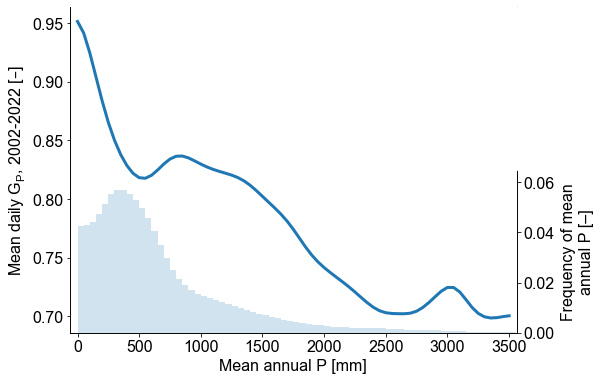

In [94]:
from matplotlib.patches import Rectangle

# mean Gp as function of mean P
bmin = 0
bmax = 3600
freq = 50
x = np.arange(bmin,bmax,freq)
meanGp_vect = []
nvect = []

for i,P in enumerate(x[:-1]):
    Gp_bin = pexq_df[(pexq_df.Pmean > P) & (pexq_df.Pmean <= x[i+1])].Gp
    meanGp_vect.append(Gp_bin.mean())
    nvect.append(Gp_bin.size)
nvect = np.array(nvect)   

#plot
fig,ax = plt.subplots(figsize=(8,6)    )
ax.plot(x[:-1],gaussian_filter1d(meanGp_vect,sigma=2),linewidth=3)
ax2 = ax.twinx()
ax2.bar(x[:-1]+freq/2,gaussian_filter1d(nvect/sum(nvect),sigma=2),width=freq,alpha=0.2)

#labels
ax.set_ylabel(r'Mean daily ${G_P}$, 2002-2022 [–]')
ax.set_xlabel('Mean annual P [mm]')
ax2.set_ylabel('Frequency of mean\nannual P [–]')
ax2.yaxis.set_label_coords(1.1, 0.25)  
ax.set_xlim(bmin-freq-10,bmax-freq+10)
ax2.set_ylim(0,0.13)
ax2.set_yticks(np.arange(0,0.061,0.02))

ax.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# cover top of ax2 yaxis
rect = Rectangle((0.9, 0.5), 0.1, 0.5, transform=ax2.transAxes, color='white', zorder=3, clip_on=False)
ax2.add_patch(rect)

### Fig S2:  Gp mean, trend, and SD, 3x products

In [38]:
# load gini data
gp_gpcc = xr.open_dataset(save_dir+'GPCC_daily_pr_gini_water_year_1982-2021.nc')
gp_cpc = xr.open_dataset(save_dir+'CPC_daily_pr_gini_water_year_1980-2020.nc')
gp_gpcp =  xr.open_dataset(save_dir+'GPCP_daily_pr_gini_water_year_1997-2022.nc')

# there is some patchy data prior to 1985 for GPCC
gp_gpcc = gp_gpcc.sel(water_year=np.arange(1985,2022))

gp_cpc = flipLon360(gp_cpc)

In [79]:
# compute summary statistics of pr gini: std dev, climatological mean
gpsd_gpcp = gp_gpcp.std(dim='water_year').Pgini_wy
gpsd_gpcc = gp_gpcc.std(dim='water_year').Pgini_wy
gpsd_cpc = gp_cpc.std(dim='year').pr_gini

gp_gpcpmean = gp_gpcp.sel(water_year=np.arange(1997,2022)).mean(dim='water_year').Pgini_wy
gp_gpccmean = gp_gpcc.sel(water_year=np.arange(1985,2021)).mean(dim='water_year').Pgini_wy
gp_cpcmean = gp_cpc.sel(year=np.arange(1980,2020)).mean(dim='year').pr_gini

gp_gpccmean = fixLonLine0(gp_gpccmean)
gp_gpccmean = fixLonLine(gp_gpccmean)
gp_gpcpmean = fixLonLine(gp_gpcpmean)
gpsd_gpcc = fixLonLine(gpsd_gpcc)
gpsd_gpcc = fixLonLine0(gpsd_gpcc)

# put on common grid and combine to dataset
gp_gpcpmean_rg = gp_gpcpmean.interp_like(gp_cpcmean)
gp_gpccmean_rg = gp_gpccmean.interp_like(gp_cpcmean)

gpmean = xr.concat([gp_gpcpmean_rg,gp_cpcmean,gp_gpccmean_rg],dim='product').mean('product')

In [100]:
# compute long-term gini trends
dGp_ds = xr.open_dataset(save_dir+'dGp_trends.nc')
dGp_mean = xr.open_dataset(save_dir+'dGp_1980-2022_3product_mean.nc')

dGp_gpcc = dGp_ds.sel(product='GPCC').dGp
dGp_gpcp = dGp_ds.sel(product='GPCP').dGp

dGp_gpcc = fixLonLine0(dGp_gpcc)
dGp_gpcc = fixLonLine(dGp_gpcc)
dGp_gpcp = fixLonLine0(dGp_gpcp)
dGp_gpcp = fixLonLine(dGp_gpcp)
dGp_gpcp = fixLonLine2(dGp_gpcp)
dGp_gpcp = fixLonLine0(dGp_gpcp)


In [76]:
# set up color maps
from matplotlib import colors
root_dir = '/dartfs-hpc/rc/lab/C/CMIG'

def hydro_cmap(vmin,vmax,ncol=13):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+2))
    cmaph = colors.ListedColormap(cols[8:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[7])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

def delta_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

def b_cmap(vmin,vmax):

    j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
    j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
    j_cmap_arr = j_cmap_arr[:68,:]
    ncol = 13
    bounds_h = np.linspace(vmin, vmax, ncol)
    cols = colors.ListedColormap(j_cmap_arr, name='j_cmap')(np.linspace(0,1,len(bounds_h)+1))
    cmaph = colors.ListedColormap(cols[1:-1])
    cmaph.set_over(cols[-1])
    cmaph.set_under(cols[1])
    normh = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    return cmaph,normh

#set up greenland mask
from cartopy.mpl.patch import geos_to_path
from shapely.geometry import Point
import cartopy.io.shapereader as shpreader


shpfilename = shpreader.natural_earth(resolution='50m',
                                      category='cultural',
                                      name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
country = next(countries)


gl_multipoly, = [country.geometry for country in countries
                 if country.attributes['NAME'] == 'Greenland']

gl_geom = sorted(gl_multipoly.geoms, key=lambda geom: geom.area)


In [41]:
j_cmap_arr = genfromtxt(os.path.join(root_dir, 'nsiegert/projects/c4mip/code/CMAP_RBGA.csv'), delimiter=',')
j_cmap_arr = np.delete(j_cmap_arr, [1,3,5], 1)
lightb = j_cmap_arr[50,:]

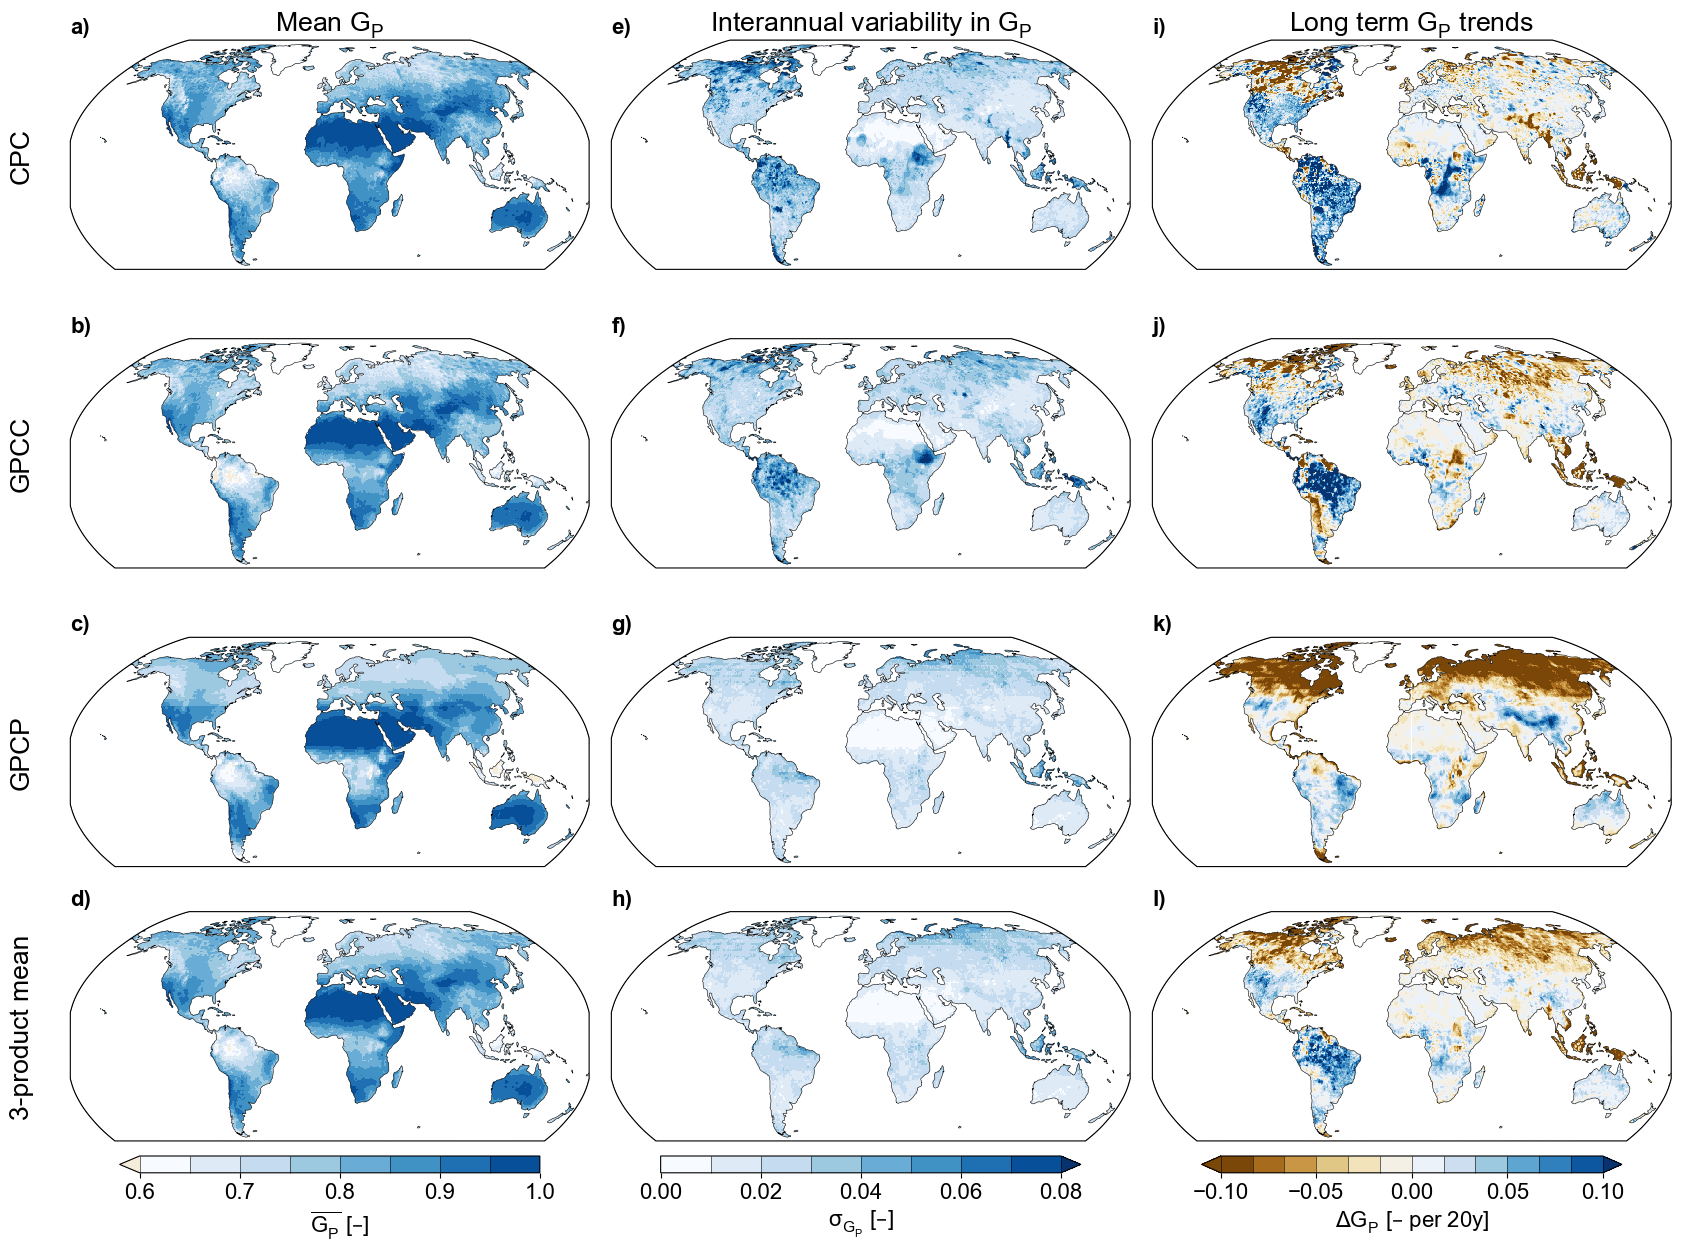

In [106]:
fig = plt.figure(figsize=(17,13))

axs = []
gs = GridSpec(4, 3)

for c in range(3):
    for r in range(4):
        
        axs.append(fig.add_subplot(gs[r,c],projection=ccrs.Robinson()))

titles = ['Mean $G_P$', 'Interannual variability in $G_P$','Long term $G_P$ trends']
products = ['CPC','GPCC','GPCP','3-product mean']

vmin = 0.6
vmax = 1
cmaph,normh = hydro_cmap(vmin,vmax,ncol=15)
lab = '$\overline{G_P}$ [–]'

#a-d) mean Gp
data2plot = [gp_cpcmean,gp_gpccmean,gp_gpcpmean,gpmean]
for i,d2p in enumerate(data2plot):
    
    ax = axs[i]
    if i < 3:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,add_colorbar=False)
    else:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.81,
                                                      'aspect':25,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

    ax.set_extent((-180,180,-58,90), crs=ccrs.PlateCarree())
    ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
    if i == 0: ax.set_title(titles[0])
    ax.text(-0.07, 0.5, products[i], va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax.transAxes,fontsize=19)
    
#e-h) sd Gp
vmin = 0
vmax = 0.08
cmaph,normh = hydro_cmap(vmin,vmax,ncol=15)
data2plot = [gpsd_cpc,gpsd_gpcc,gpsd_gpcp,gpsd_gpcp]
lab = '$\sigma_{G_P}$ [–]'
for i,d2p in enumerate(data2plot):
    
    ax = axs[i+4]
    
    if i < 3:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,add_colorbar=False)
    else:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.81,
                                                      'aspect':25,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

    ax.set_extent((-180,180,-58,90), crs=ccrs.PlateCarree())
    ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
    if i==0: ax.set_title(titles[1])


#i-l) Gp trends
vmin = -0.1
vmax = 0.1
cmaph,normh = delta_cmap(vmin,vmax)
lab = '$\Delta G_P$ [– per 20y]'
data2plot = [dGp_ds.sel(product='CPC').dGp,dGp_gpcc,dGp_gpcp,dGp_mean.polyfit_coefficients]

for i,d2p in enumerate(data2plot):
    
    ax = axs[i+8]
    if i < 3:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,add_colorbar=False)
    else:
        d2p.plot(transform=ccrs.PlateCarree(),ax=ax,cmap=cmaph,norm=normh,
                     vmax=vmax,vmin=vmin,cbar_kwargs={'orientation':'horizontal',
                                                      'shrink':0.81,
                                                      'aspect':25,
                                                      'label':lab,
                                                      'pad':0.05,
                                                      'drawedges':True})

    ax.set_extent((-180,180,-58,90), crs=ccrs.PlateCarree())
    ax.add_geometries(gl_geom,ccrs.PlateCarree(),facecolor='white')
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='black',facecolor='white',linewidth=0.4) 
    if i>0: ax.set_title('')
    else: ax.set_title(titles[2])


# lettering
lets = 'abcdefghijkl'
for i,ax in enumerate(axs):
    ax.text(-0.0,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    

fig.canvas.draw()
plt.tight_layout(w_pad=1,h_pad=0.1)



### Fig. S3: relative conditional TWS effect

In [5]:
# calculate conditional marginal effect +/- SE
scale = 0.1
scale = scale*cm_to_mm
n_se = 2
#conditional coef estimates
gamma_abs = -15.790
chi_abs = -0.007
gamma_se = 4.465
chi_se = 0.004
cov_gamma_chi = -0.0127

#same coefs for GPCP data
gamma_gpcp_abs = -19.38
chi_gpcp_abs = -0.019
gamma_gpcp_se = 5.242
chi_gpcp_se = 0.008
cov_gpcp_gamma_chi = -0.0316

# same for GPCC
gamma_gpcc_abs = -18.33
chi_gpcc_abs = -0.008
gamma_gpcc_se = 2.990
chi_gpcc_se = 0.003
cov_gpcc_gamma_chi = -5.801565e-03

# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x


In [25]:
norms = []
for b in x:
    norms.append(pexq_df.loc[(pexq_df.Pmean <= b+100) & (pexq_df.Pmean > b)].groupby('gridindex')['LWE'].std().mean()*10)


In [31]:
normsfilt = gaussian_filter1d(norms,sigma=2)

In [26]:
ys = gaussian_filter1d(y/norms,sigma=2)
ygpccs = gaussian_filter1d(ygpcc/norms,sigma=2)
ygpcps = gaussian_filter1d(ygpcp/norms,sigma=2)


Text(0.5, 1.0, 'Relative marginal effect of $G_P$ on TWS')

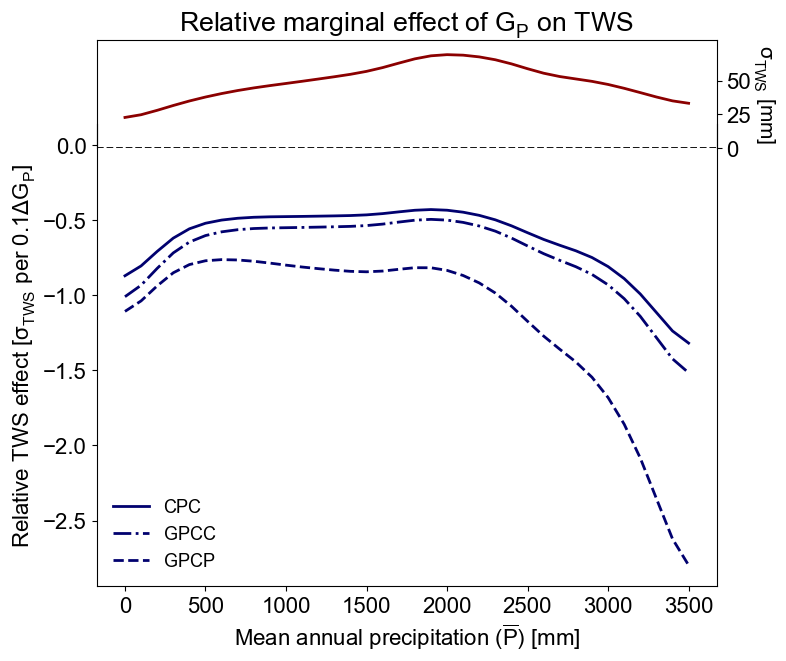

In [120]:
col_p = '#01016f'
col_t = '#d8031c'
col_gp = '#c2e4f0'
col_gp1000 = '#aecde8'
col_gp2000 = '#9ac2ed'
col_gp3000 = '#7bb2ed'

fig,ax = plt.subplots(figsize=(8,6))
##############
# a) conditional gamma
#cpc
l1=ax.plot(x,ys,color=col_p,linewidth=2)
#s1 = ax.fill_between(x,effecthi,effectlo,color=col_gp1000,alpha=0.5)

#gpcp
l2=ax.plot(x,ygpcps,color=col_p,linewidth=2,linestyle='--')
#s2 = ax.fill_between(x,effecthi_gpcp,effectlo_gpcp,color=col_gp1000,alpha=0.5)

#gpcc
l3=ax.plot(x,ygpccs,color=col_p,linewidth=2,linestyle='-.')
#s3 = ax.fill_between(x,effecthi_gpcc,effectlo_gpcc,color=col_gp1000,alpha=0.5)

ax.axhline(0,linestyle='--',color='white')
ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')
ax.set_ylabel('Relative TWS effect ' + r'[$\sigma_{TWS}$ per $0.1 \Delta{G_P}$]')
#ax.text(0.6,0.8,r'$\frac{\partial {LWE}} {\partial{G_P}} = \gamma + \chi \overline{P}$',transform=ax.transAxes)

#ax.axvline(1000,linestyle='--',color='#a38bbf')
#ax.text(850,-87,'Global mean',fontsize=13,rotation=90)
#legend
lg=ax.legend([l1[0],l3[0],l2[0]],['CPC','GPCC','GPCP'],
             loc='lower left',facecolor='white',edgecolor='white',fontsize=13)
lg.get_frame().set_alpha(0)

ax.spines['top'].set_visible(False)


# add TWS SD plot

bar_ax = fig.add_axes([0.125,0.84,0.775,0.18])
bar_ax.plot(x,normsfilt,color='darkred',linewidth=2)

bar_ax.axhline(y=0,linewidth=1.3,color="black", linestyle="--")
bar_ax.spines["right"].set_visible(True)
bar_ax.spines["top"].set_visible(True)
bar_ax.spines["left"].set_visible(True)
bar_ax.spines["bottom"].set_visible(False)
#bar_ax.set_yticks([])
bar_ax.yaxis.set_label_position("right")
bar_ax.yaxis.tick_right()
bar_ax.set_yticks([0,25,50])
bar_ax.set_ylim(0,80)
#bar_ax.set_yticklabels(labels=["-1","0","1"], fontsize=15)
bar_ax.set_ylabel("$\sigma_{TWS}$ [mm]",
                 fontsize=15,rotation=270,labelpad=18)
bar_ax.set_xticks([])
#plt.text(0.8,0.7,"GDPpc relative to"+"\n"+"global mean (frac.)",
#         transform=bar_ax.transAxes,fontsize=15,ha="center")
bar_ax.patch.set_alpha(0)

bar_ax.set_title(r'Relative marginal effect of $G_P$ on TWS'  )


### Fig. S10: variable pairwise correlation matrix

[Text(0, 0.5, 'P'),
 Text(0, 1.5, 'T'),
 Text(0, 2.5, 'Abs. $G_P$'),
 Text(0, 3.5, '$G_P$ Anom.'),
 Text(0, 4.5, '$\\overline{P}$')]

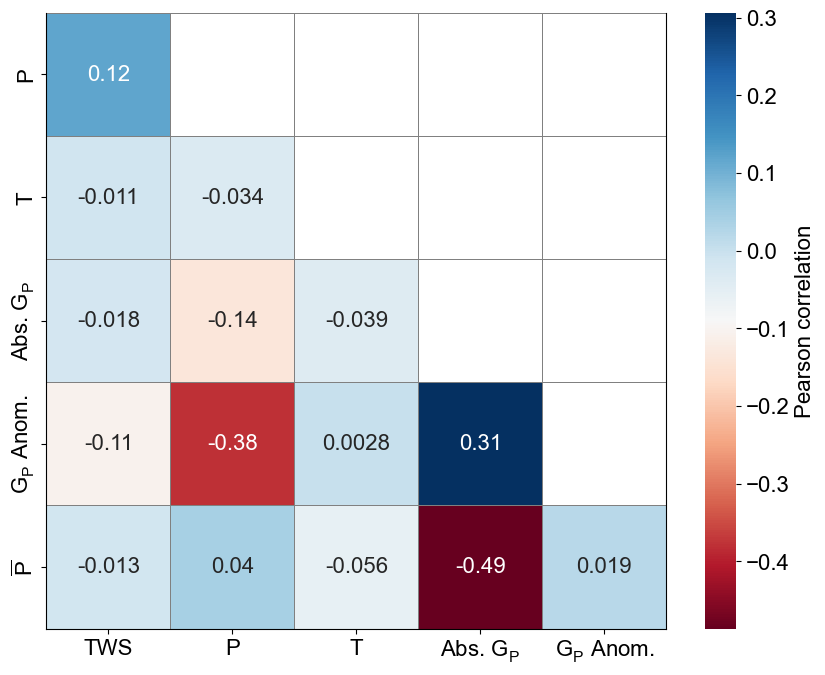

In [27]:
fig,ax = plt.subplots(figsize=(10,8))
#set up panel
pexq_df = pexq_df[~pexq_df.water_year.isin([2002,2017,2022])]
varbs = list(pexq_df.columns)[3:9]
dfsub = pexq_df[varbs]
# pairwise correlation matrixs
corr_matrix = dfsub.corr()
# grab only lower triangle
upperfull = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))

# skew the matrix by 1 to omit correlation between same variable
upper = upperfull[1:][['LWE','P','T','Gp','Gp_anoms']]

#plot
sns.heatmap(upper, ax=ax,cmap="RdBu", linecolor='grey',linewidths=0.5,annot=True,cbar_kws={'label':'Pearson correlation'})
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["right"].set_visible(True)

ax.set_xticklabels(['TWS','P','T','Abs. $G_P$','$G_P$ Anom.'])
ax.set_yticklabels(['P','T','Abs. $G_P$','$G_P$ Anom.','$\overline{P}$'])

### Fig. S4: plot basin level all obs

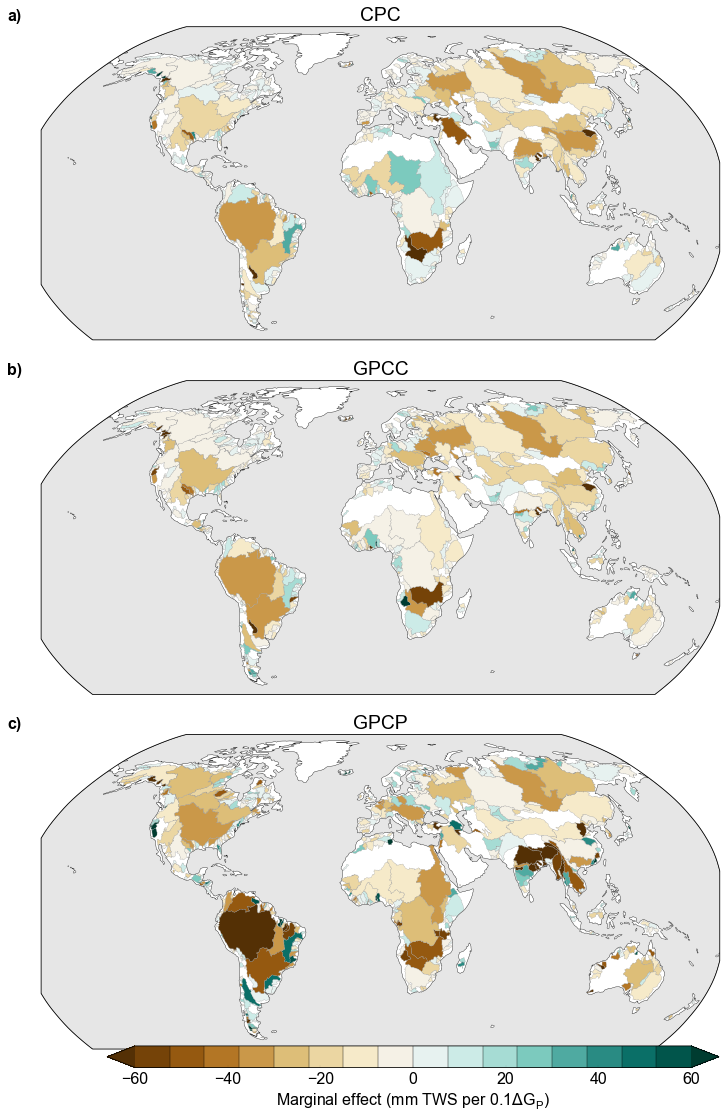

In [42]:
dset = ['CPC','GPCC','GPCP']
dset_suffix = ['','_GPCC','_GPCP']


fig = plt.figure(figsize=(10,15))

axs = []
gs = GridSpec(3, 1)

axs.append(fig.add_subplot(gs[0,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[1,0],projection=ccrs.Robinson()))
axs.append(fig.add_subplot(gs[2,0],projection=ccrs.Robinson()))

for i,ax in enumerate(axs):
    basin_models = pd.read_csv(save_dir+'basin_models_no_interaction'+dset_suffix[i]+'.csv')
    grdc_basins = gp.read_file('/dartfs-hpc/rc/lab/C/CMIG/Data/Other/grdc_basins/grdc_basins_2.shp')

    grdc_basins = grdc_basins.rename(columns={'MRBID':'basin_id'})
    merged = grdc_basins.merge(basin_models, on='basin_id', how='left')

    #select column to plot
    plotdat = 'coef_Gp'
    sigdat = 'pval_Gp'

    # set colors
    vmin = -60
    vmax = 60
    ncol = 17 # choose a number greater than
             # the number of colors you actually want
    bounds = np.linspace(vmin,vmax,ncol)
    cmapname = 'BrBG'
    cols = plt.get_cmap(cmapname)(np.linspace(0,1,len(bounds)+1))
    cmap = colors.ListedColormap(cols[1:-1])
    cmap.set_over(cols[-1])
    cmap.set_under(cols[0])
    norm = colors.Normalize(vmin=vmin,vmax=vmax)
    cbar = plt.cm.ScalarMappable(norm=norm,cmap=cmap)

    # map
    merged.plot(column=plotdat,transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, linewidth=0.2, ax=ax, edgecolor='0.6', legend=False)

    ax.set_extent((-170,180,-60,90), crs=ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,edgecolor='0.1',facecolor=[0.9,0.9,0.9],linewidth=0.4) 

    hatch_polygons = merged[merged[sigdat] > 0.05]
    hatch_polygons.plot(
        ax=ax, 
        facecolor="none",  # No fill color for hatching layer
        edgecolor='0.6',   # Keep border color consistent
        hatch='/////',      # Choose your hatch pattern
        linewidth=0.2
    )

    ax.set_title(dset[i])
    
cbar_ax = fig.add_axes([0.125,0.0,0.85,0.02])
plt.setp(cbar_ax.spines.values(), linewidth=0.3)
#tks = [-2,-1,0,1,2]
cb = fig.colorbar(cbar,cax=cbar_ax,orientation="horizontal",
                          drawedges=True,extend="both")#,ticks=tks)
cbar_ax.tick_params(direction="in",width=0.05)
cb.set_label(label=r"Marginal effect (mm TWS per 0.1$\Delta G_P$)")

# lettering
lets = 'abcdefghi'

for i,ax in enumerate(axs):
    ax.text(-0.05,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')

fig.canvas.draw()
plt.tight_layout()


### Fig. S5: distribution effect across data products

In [100]:
# function to compute 95% estimation CI of fit
def intSE(y,se_Gp,se_GpP,cov,scale=1,n_se=2):
    variance = se_Gp**2 + (x**2) * se_GpP**2 + 2*x * cov
    se = np.sqrt(variance)
    effecthi = y+scale*n_se*se
    effectlo = y-scale*n_se*se
    return effectlo,effecthi

scale = 0.1*10
n_se = 2


In [101]:
# load distributional effect regression results (and main model results, for comparison)
cpc_results_SW = pd.read_csv(save_dir+'reg_results/CPC_regression_results_SWint.csv')
cpc_results = pd.read_csv(save_dir+'reg_results/CPC_regression_results.csv')

gpcp_results_SW = pd.read_csv(save_dir+'reg_results/GPCP_regression_results_SWint.csv')
gpcp_results = pd.read_csv(save_dir+'reg_results/GPCP_regression_results.csv')

gpcc_results_SW = pd.read_csv(save_dir+'reg_results/GPCC_regression_results_SWint.csv')
gpcc_results = pd.read_csv(save_dir+'reg_results/GPCC_regression_results.csv')

In [103]:
# range of mean P to sample conditional effect over:
bmin = 0
bmax = 3600
freq = 100
x = np.arange(bmin,bmax,freq)

# calculate regression lines
ysw_cpc = scale*cpc_results_SW.coef_Gp[0]+scale*cpc_results_SW.coef_GpP[0]*x
y_cpc = scale*gamma_abs+scale*chi_abs*x

ysw_gpcc = scale*gpcc_results_SW.coef_Gp[0]+scale*gpcc_results_SW.coef_GpP[0]*x
y_gpcc = scale*gpcc_results.coef_Gp[0]+scale*gpcc_results.coef_GpP[0]*x

ysw_gpcp = scale*gpcp_results_SW.coef_Gp[0]+scale*gpcp_results_SW.coef_GpP[0]*x
y_gpcp = scale*gpcp_results.coef_Gp[0]+scale*gpcp_results.coef_GpP[0]*x

#uncertainty for distributional:

effectlosw_cpc, effecthisw_cpc = intSE(ysw_cpc,cpc_results_SW.se_Gp[0],cpc_results_SW.se_GpP[0],cpc_results_SW.vcov[0])
effectlosw_gpcp, effecthisw_gpcp = intSE(ysw_gpcp,gpcp_results_SW.se_Gp[0],gpcp_results_SW.se_GpP[0],gpcp_results_SW.vcov[0])
effectlosw_gpcc, effecthisw_gpcc = intSE(ysw_gpcc,gpcc_results_SW.se_Gp[0],gpcc_results_SW.se_GpP[0],gpcc_results_SW.vcov[0])

#uncertainty main model:
effectlo_cpc, effecthi_cpc = intSE(y_cpc,cpc_results.se_Gp[0],cpc_results.se_GpP[0],cpc_results.vcov[0])
effectlo_gpcp, effecthi_gpcp = intSE(y_gpcp,gpcp_results.se_Gp[0],gpcp_results.se_GpP[0],gpcp_results.vcov[0])
effectlo_gpcc, effecthi_gpcc = intSE(y_gpcc,gpcc_results.se_Gp[0],gpcc_results.se_GpP[0],gpcc_results.vcov[0])


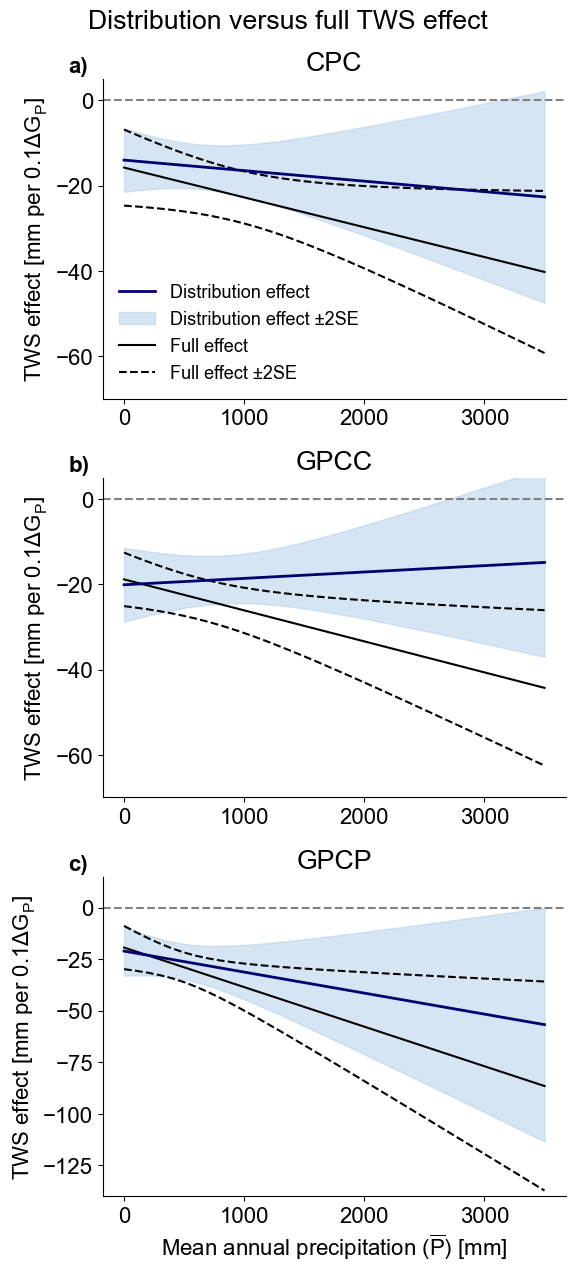

In [122]:
# setup axes
fig = plt.figure(figsize=(6,13))

axs = []
gs = GridSpec(3, 1)

axs.append(fig.add_subplot(gs[0,:]))
axs.append(fig.add_subplot(gs[1,:]))
axs.append(fig.add_subplot(gs[2,:]))

# data products
prdts = ['CPC','GPCC','GPCP']
ylims = [[-70,5],[-70,5],[-140,15]]
fsizel = 13

# assemble data to plot
ysw_data = [ysw_cpc,ysw_gpcc,ysw_gpcp]
ysw_shademin = [effectlosw_cpc,effectlosw_gpcc,effectlosw_gpcp]
ysw_shademax = [effecthisw_cpc,effecthisw_gpcc,effecthisw_gpcp]
y_data = [y_cpc,y_gpcc,y_gpcp]
y_shademin = [effectlo_cpc,effectlo_gpcc,effectlo_gpcp]
y_shademax = [effecthi_cpc,effecthi_gpcc,effecthi_gpcp]

# loop over data products and plot distributional and full effects
for i,ax in enumerate(axs):
    color='cadetblue'

    l0=ax.plot(x,y_data[i],'k-')
    l1=ax.plot(x,y_shademin[i],'k--')
    ax.plot(x,y_shademax[i],'k--')

    l2=ax.plot(x,ysw_data[i],color='#01016f',linewidth=2)
    f0=ax.fill_between(x,ysw_shademin[i],ysw_shademax[i],color='#aecde8',alpha=0.5)
    ax.axhline(0,linestyle='--',color='grey')
    
    if ax==axs[0]:
        ax.legend([l2[0],f0,l0[0],l1[0]],['Distribution effect',
                                          'Distribution effect ±2SE',
                                          'Full effect',
                                          'Full effect ±2SE'],
                  fontsize=fsizel,frameon=False)

   
    ax.set_ylabel('TWS effect [mm per $0.1 \Delta G_P$]')

    if ax==axs[2]:
        ax.set_xlabel('Mean annual precipitation ('+r'$\overline{P}$) [mm]')

    ax.set_title(prdts[i])
    ax.set_ylim(ylims[i])


###
lets = 'abcdcd'
# axis adjustments
for i,ax in enumerate(axs):
    ax.spines[['right', 'top']].set_visible(False)
    ax.text(-0.075,1.02,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
fig.suptitle('Distribution versus full TWS effect')
plt.tight_layout(pad=1,w_pad=2)

### Fig. S6 -- just a schematic -- no data

### Fig. S7 -- see notebook 'lesk+mankin_SEMBH.ipynb' for model and sample figure

### Fig S8: SEMBH sensitivity

In [107]:
#load median parameter runs
rsdf = pd.read_csv(save_dir + 'semhb_model_runs.csv')


In [108]:
prange = np.arange(0,3300,200)


In [109]:
# adjust to effect per 0.1 delta Gp, linearly
dTWSc = rsdf.dTWS*0.1/rsdf.dGp
rsdf['dTWSc'] = dTWSc
rsdf = rsdf.dropna()
rsdf = rsdf[(rsdf['dTWSc'] <= 1000) & (rsdf['dTWSc'] >= -1000)]

rsdf['dETlakec'] = rsdf.dETlake*0.1/rsdf.dGp
rsdf['dETlandc'] = rsdf.dETland*0.1/rsdf.dGp
rsdf['dQoutc'] = rsdf.dQout*0.1/rsdf.dGp
rsdf['dQinc'] = rsdf.dQ*0.1/rsdf.dGp

# compute modeled relationship between ET and Gp
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(rsdf.pmean, rsdf.dTWSc)

# compute CI of model dTWSc/dGp
X = sm.add_constant(rsdf['pmean'].values)
ols_model = sm.OLS(rsdf['dTWSc'].values, X)
est = ols_model.fit()
pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

# line and range
line = slope*prange+intercept

lower = pred['mean_ci_lower']
upper = pred['mean_ci_upper']




In [110]:
# empirical results, for comparison:
#calculate conditional marginal effect +/- SE

scale = 0.1*10 # per 0.1 Gp, * 10mm per cm
n_se = 2
#conditional coef estimates
gamma_abs = -15.790
chi_abs = -0.007
gamma_se = 4.465
chi_se = 0.004
cov_gamma_chi = -0.0127

#same coefs for GPCP data
gamma_gpcp_abs = -19.38
chi_gpcp_abs = -0.019
gamma_gpcp_se = 5.242
chi_gpcp_se = 0.008
cov_gpcp_gamma_chi = -0.0316

# same for GPCC
gamma_gpcc_abs = -18.33
chi_gpcc_abs = -0.008
gamma_gpcc_se = 2.990
chi_gpcc_se = 0.003
cov_gpcc_gamma_chi = -5.801565e-03

# range of mean P to sample conditional effect over:
x = prange
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#average of 3 pr obs 
empirical = np.mean(np.array([y,ygpcp,ygpcc]),axis=0)

In [111]:
# compute quantiles of model distribution
dTWS_10 = rsdf.groupby('Key').quantile(0.1).dTWSc
dTWS_90 = rsdf.groupby('Key').quantile(0.9).dTWSc
dTWS_25 = rsdf.groupby('Key').quantile(0.25).dTWSc
dTWS_75 = rsdf.groupby('Key').quantile(0.75).dTWSc

#compute water budget terms
dETld = rsdf.groupby('Key').dETlandc.mean()
dETlk = rsdf.groupby('Key').dETlakec.mean()
dET = dETld + dETlk
dQ = rsdf.groupby('Key').dQoutc.mean()
dQin = rsdf.groupby('Key').dQinc.mean()

#compute water budget terms
dETld_sd = rsdf.groupby('Key').dETlandc.std()
dETlk_sd = rsdf.groupby('Key').dETlakec.std()
dQ_sd = rsdf.groupby('Key').dQoutc.std()
dQin_sd = rsdf.groupby('Key').dQinc.std()

In [112]:
# load perturbed parameter experiment results
rsdfppe = pd.read_csv(save_dir+'SEMBH_model_runs_PPE.csv')


In [113]:
# adjust to effect per 0.1 delta Gp, linearly
dTWSc_ppe = rsdfppe.dTWS*0.1/rsdfppe.dGp
rsdfppe['dTWSc'] = dTWSc_ppe
rsdfppe = rsdfppe.dropna()
rsdfppe = rsdfppe[(rsdfppe['dTWSc'] <= 1000) & (rsdfppe['dTWSc'] >= -1000)]

rsdfppe['dETlakec'] = rsdfppe.dETlake*0.1/rsdfppe.dGp
rsdfppe['dETlandc'] = rsdfppe.dETland*0.1/rsdfppe.dGp
rsdfppe['dQoutc'] = rsdfppe.dQout*0.1/rsdfppe.dGp
rsdfppe['dQinc'] = rsdfppe.dQ*0.1/rsdfppe.dGp

# load parameter sets
pspace = pd.read_csv(save_dir+'SEMBH_parameter_sets.csv')


In [114]:
# compute modeled relationship between TWSc and Gp for each param set
lines = {}
slopes = {}

sdf = pd.DataFrame(columns=['param_set','slope','intercept','pvalue','se'])

for p in pspace.index:
    
    rdfsub = rsdfppe[rsdfppe.paramset == p]
    slope, intercept, r_value, p_value, std_err = linregress(rdfsub.pmean, rdfsub.dTWSc)
    sdf.loc[p] = [p,slope,intercept,p_value,std_err]
    
    # compute CI of model dTWSc/dGp
    X = sm.add_constant(rdfsub['pmean'].values)
    ols_model = sm.OLS(rdfsub['dTWSc'].values, X)
    est = ols_model.fit()
    pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

    # line and range
    slopes[str(p)] = slope
    lines[str(p)] = slope*prange+intercept

    lower_ppe = pred['mean_ci_lower']
    upper_ppe = pred['mean_ci_upper']


examine parameter importance

In [115]:
# setup parameter space
pspace.index = pd.to_numeric(pspace.index)

sdf = pd.concat([pspace,sdf],axis=1)
sdf = sdf.drop(columns=sdf.columns[0])

In [116]:
params_space = {'CN': [30,50,80],
                'outflow_rate': [0.001,0.005,0.01],
                'a_l':  [0.01,0.1,0.25],
                'h_l': [1,5,10],
                'v_H': [8,10,12]
               }

y = sdf['intercept']
X = sdf[['outflow_rate', 'CN', 'a_l', 'h_l', 'v_H']]

# Add a constant to the model (for the intercept term)
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()


In [118]:
normcoefs = [model.params[i]*(max(params_space[i])-min(params_space[i])) for  i in params_space]
labs = list(params_space.keys())
prs = sorted(zip(normcoefs, labs))
svals, sstrs = zip(*prs)


In [120]:
# load Sobol' indices -- see notebook 'lesk+mankin_GVBSA.ipynb'
rdf_first = pd.read_csv(save_dir+'GVBSA_indices_first_order_N10.csv')
rdf_total = pd.read_csv(save_dir+'GVBSA_indices_total_order_N10.csv')

0.5635113932109335
0.28754646382811094
0.0008006096387922914
0.000802245877124288
0.00768515519440061


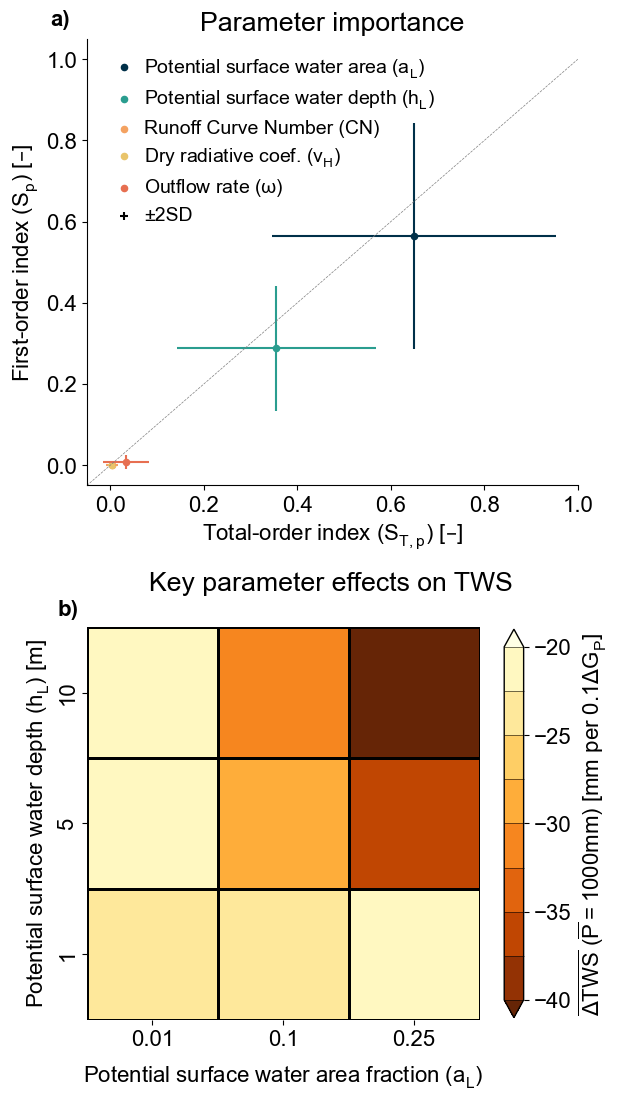

In [126]:
fig = plt.figure(figsize=(6,11))

axs = []
gs = GridSpec(2, 1)

lfsize = 14

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))

### a) parameter effects
ax = axs[0]

prms = list(rdf_first.columns[1:])
#clrs = ['#1a53ff',  '#40916c', '#7c1158',  '#ffb501','#b30000']
clrs = ['#003049','#2a9d8f','#f4a261','#e9c46a','#e76f51']
labs = ['Potential surface water area ($a_L$)','Potential surface water depth ($h_L$)','Runoff Curve Number (CN)',
        'Dry radiative coef. ($v_H$)','Outflow rate ($\omega$)','±2SD']

prms = ['a_l','h_l','CN','v_H','outflow_rate']

pts = []
    
for i,prm in enumerate(prms):
    print(rdf_first[prm].mean())

    pt=ax.scatter(rdf_total[prm].mean(),rdf_first[prm].mean(),c=clrs[i],s=20)
    ax.errorbar(rdf_total[prm].mean(),rdf_first[prm].mean(),
                xerr=2*rdf_total[prm].std(),
                yerr=2*rdf_first[prm].std(),
                c=clrs[i])
    pts.append(pt)

ax.set_ylabel('First-order index ($S_p$) [–]')
ax.set_xlabel('Total-order index ($S_{T,p}$) [–]')
l=ax.scatter([],[],marker='+',color='k')
ax.legend(pts+[l],labs,fontsize=lfsize,
          frameon=False,
          loc='upper left',
          labelspacing=0.4,
          handletextpad=0.05)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1)
ax.plot([-0.05,1],[-.05,1],linestyle='--',color='grey',linewidth=0.5)
ax.set_title('Parameter importance')



### b) bivariate parameter effects 1:
ax = axs[1]

#colormap
vmin = -40
vmax = -20
ncol = 9 # choose a number greater than
         # the number of colors you actually want
bounds = np.linspace(vmin,vmax,ncol)
cmapname = 'YlOrBr_r'
cols = plt.get_cmap(cmapname)(np.linspace(0,1,len(bounds)+1))
cmap = matplotlib.colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = matplotlib.colors.Normalize(vmin=vmin,vmax=vmax)
cbar = plt.cm.ScalarMappable(norm=norm,cmap=cmap)


hm=sns.heatmap(dTWS_params,cmap=cmap,norm=norm,ax=ax,cbar=True,
               linecolor='black',linewidth=1,
               cbar_kws={'drawedges':True,                                           
                          'extend':"both",
                          'shrink':0.87,
                          'ticks':[-40,-35,-30,-25,-20],
                          'label':'$\overline{\Delta TWS}$ $(\overline{P}=1000mm) $ [mm per $0.1 \Delta G_P$]'})

colorbar = hm.collections[0].colorbar
colorbar.outline.set_edgecolor('black')
colorbar.outline.set_linewidth(1)

ax.set_xlabel('Potential surface water area fraction (' + r'$a_L$)',labelpad=10)
ax.set_yticklabels(params_space['h_l'])
ax.set_ylabel('Potential surface water depth ($h_L$) [m]')
ax.set_xticklabels(params_space['a_l'])
ax.set_title('             Key parameter effects on TWS\n',ha='center')
ax.invert_yaxis()

ax.set_box_aspect(1.0)



# lettering and spines
lets = 'abcdefghi'
for i,ax in enumerate(axs):
    if i < 3:
        ax.spines[['right', 'top']].set_visible(False)
    else:
        ax.spines[['right', 'bottom']].set_visible(True)

    ax.text(-0.075,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    
plt.tight_layout(pad=0.0)
#plt.savefig('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/figs/clean/Fig.4.pdf',bbox_inches='tight')

### Fig. S9 -- see notebook with projection calculations ('Lesk+Mankin_projections.ipynb')

### Fig. S11 -- SEMBH results with surface temperature set by soil and surface water ET

In [21]:
#load median parameter runs with surface water ET contribution to surface Temp
rsdf = pd.read_csv(save_dir + 'SEMBH_model_runs_ETl_N100.csv')


In [22]:
prange = np.arange(0,3300,200)


In [23]:
# adjust to effect per 0.1 delta Gp, linearly
dTWSc = rsdf.dTWS*0.1/rsdf.dGp
rsdf['dTWSc'] = dTWSc
rsdf = rsdf.dropna()
rsdf = rsdf[(rsdf['dTWSc'] <= 1000) & (rsdf['dTWSc'] >= -1000)]

rsdf['dETlakec'] = rsdf.dETlake*0.1/rsdf.dGp
rsdf['dETlandc'] = rsdf.dETland*0.1/rsdf.dGp
rsdf['dQoutc'] = rsdf.dQout*0.1/rsdf.dGp
rsdf['dQinc'] = rsdf.dQ*0.1/rsdf.dGp

# compute modeled relationship between ET and Gp
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(rsdf.pmean, rsdf.dTWSc)

# compute CI of model dTWSc/dGp
X = sm.add_constant(rsdf['pmean'].values)
ols_model = sm.OLS(rsdf['dTWSc'].values, X)
est = ols_model.fit()
pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

# line and range
line = slope*prange+intercept

lower = pred['mean_ci_lower']
upper = pred['mean_ci_upper']




In [24]:
# empirical results, for comparison:
#calculate conditional marginal effect +/- SE

scale = 0.1*10 # per 0.1 Gp, * 10mm per cm
n_se = 2
#conditional coef estimates
gamma_abs = -15.790
chi_abs = -0.007
gamma_se = 4.465
chi_se = 0.004
cov_gamma_chi = -0.0127

#same coefs for GPCP data
gamma_gpcp_abs = -19.38
chi_gpcp_abs = -0.019
gamma_gpcp_se = 5.242
chi_gpcp_se = 0.008
cov_gpcp_gamma_chi = -0.0316

# same for GPCC
gamma_gpcc_abs = -18.33
chi_gpcc_abs = -0.008
gamma_gpcc_se = 2.990
chi_gpcc_se = 0.003
cov_gpcc_gamma_chi = -5.801565e-03

# range of mean P to sample conditional effect over:
x = prange
y = scale*gamma_abs+scale*chi_abs*x
ygpcp = scale*gamma_gpcp_abs+scale*chi_gpcp_abs*x
ygpcc = scale*gamma_gpcc_abs+scale*chi_gpcc_abs*x

#uncertainty:
variance = gamma_se**2 + (x**2) * chi_se**2 + 2 * x * cov_gamma_chi
se = np.sqrt(variance)
effecthi = y+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo = y-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x
#gpcp
variance = gamma_gpcp_se**2 + (x**2) * chi_gpcp_se**2 + 2 * x * cov_gpcp_gamma_chi
se = np.sqrt(variance)
effecthi_gpcp = ygpcp+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcp = ygpcp-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#gpcc
variance = gamma_gpcc_se**2 + (x**2) * chi_gpcc_se**2 + 2 * x * cov_gpcc_gamma_chi
se = np.sqrt(variance)
effecthi_gpcc = ygpcc+scale*n_se*se# scale*(gamma_abs-n_se*gamma_se) + scale*(chi_abs+n_se*chi_se)*x
effectlo_gpcc = ygpcc-scale*n_se*se# scale*(gamma_abs+n_se*gamma_se) + scale*(chi_abs-n_se*chi_se)*x

#average of 3 pr obs 
empirical = np.mean(np.array([y,ygpcp,ygpcc]),axis=0)

In [25]:
# compute quantiles of model distribution
dTWS_10 = rsdf.groupby('Key').quantile(0.1).dTWSc
dTWS_90 = rsdf.groupby('Key').quantile(0.9).dTWSc
dTWS_25 = rsdf.groupby('Key').quantile(0.25).dTWSc
dTWS_75 = rsdf.groupby('Key').quantile(0.75).dTWSc

#compute water budget terms
dETld = rsdf.groupby('Key').dETlandc.mean()
dETlk = rsdf.groupby('Key').dETlakec.mean()
dET = dETld + dETlk
dQ = rsdf.groupby('Key').dQoutc.mean()
dQin = rsdf.groupby('Key').dQinc.mean()

#compute water budget terms
dETld_sd = rsdf.groupby('Key').dETlandc.std()
dETlk_sd = rsdf.groupby('Key').dETlakec.std()
dQ_sd = rsdf.groupby('Key').dQoutc.std()
dQin_sd = rsdf.groupby('Key').dQinc.std()

In [26]:
# load perturbed parameter experiment results
rsdfppe = pd.read_csv(save_dir+'SEMBH_model_runs_PPE.csv')


In [27]:


# adjust to effect per 0.1 delta Gp, linearly
dTWSc_ppe = rsdfppe.dTWS*0.1/rsdfppe.dGp
rsdfppe['dTWSc'] = dTWSc_ppe
rsdfppe = rsdfppe.dropna()
rsdfppe = rsdfppe[(rsdfppe['dTWSc'] <= 1000) & (rsdfppe['dTWSc'] >= -1000)]

rsdfppe['dETlakec'] = rsdfppe.dETlake*0.1/rsdfppe.dGp
rsdfppe['dETlandc'] = rsdfppe.dETland*0.1/rsdfppe.dGp
rsdfppe['dQoutc'] = rsdfppe.dQout*0.1/rsdfppe.dGp
rsdfppe['dQinc'] = rsdfppe.dQ*0.1/rsdfppe.dGp

# load parameter sets
pspace = pd.read_csv(save_dir+'SEMBH_parameter_sets.csv')




In [28]:
# compute modeled relationship between TWSc and Gp for each param set
lines = {}
slopes = {}

sdf = pd.DataFrame(columns=['param_set','slope','intercept','pvalue','se'])

for p in pspace.index:
    
    rdfsub = rsdfppe[rsdfppe.paramset == p]
    slope, intercept, r_value, p_value, std_err = linregress(rdfsub.pmean, rdfsub.dTWSc)
    sdf.loc[p] = [p,slope,intercept,p_value,std_err]
    
    # compute CI of model dTWSc/dGp
    X = sm.add_constant(rdfsub['pmean'].values)
    ols_model = sm.OLS(rdfsub['dTWSc'].values, X)
    est = ols_model.fit()
    pred = est.get_prediction(sm.add_constant(prange)).summary_frame()

    # line and range
    slopes[str(p)] = slope
    lines[str(p)] = slope*prange+intercept

    lower_ppe = pred['mean_ci_lower']
    upper_ppe = pred['mean_ci_upper']


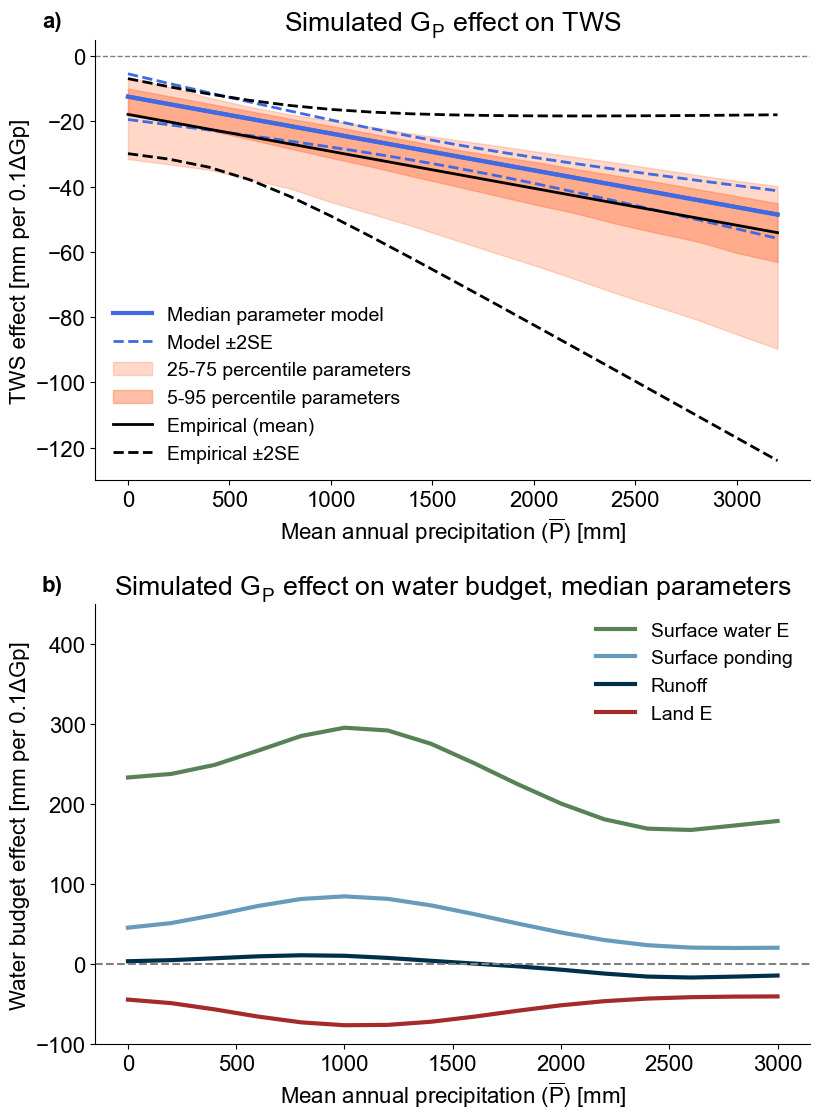

In [ ]:
fig = plt.figure(figsize=(8,11))

axs = []
gs = GridSpec(2, 1)

lfsize = 14

axs.append(fig.add_subplot(gs[0,0]))
axs.append(fig.add_subplot(gs[1,0]))

### a) TWS effect, median params
ax = axs[0]

#model model
l0 = ax.plot(prange, line,linewidth=3,color='royalblue')
#f0 = ax.fill_between(prange,line-2*(line-lower),line+2*(upper-line),alpha=0.9,color='darkturquoise')
#f0 = ax.fill_between(prange,lower,upper,alpha=0.9,color='darkturquoise')
l1 = ax.plot(prange,lower,color='royalblue',linestyle='--',linewidth=2)
ax.plot(prange,upper,color='royalblue',linestyle='--',linewidth=2)

#empirical model
l2 = ax.plot(prange,empirical,color='black',linewidth=2)
l3 = ax.plot(prange,effecthi,color='black',linestyle='--',linewidth=2)
ax.plot(prange,effectlo_gpcp,color='black',linestyle='--',linewidth=2)

# Compute the 5th and 95th percentiles along the columns (axis=0)
pln_5 = np.percentile(stacked, 5, axis=0)
pln_95 = np.percentile(stacked, 95, axis=0)
pln_25 = np.percentile(stacked, 25, axis=0)
pln_75 = np.percentile(stacked, 75, axis=0)

l0 = ax.plot(prange, line,linewidth=3,color='royalblue')
f0 = ax.fill_between(prange,pln_5,pln_95,color='coral',alpha=0.3)
f1 = ax.fill_between(prange,pln_25,pln_75,color='coral',alpha=0.5)

#individual run percentiles
#f1 = ax.fill_between(prange,dTWS_10,dTWS_90,alpha=0.1,color='darkturquoise')
#f2 = ax.fill_between(prange,dTWS_25,dTWS_75,alpha=0.3,color='darkturquoise')

ax.axhline(0,linestyle='--',color='grey',linewidth=1)


ax.legend([l0[0],l1[0],f0,f1,l2[0],l3[0]],
          ['Median parameter model','Model ±2SE','25-75 percentile parameters','5-95 percentile parameters','Empirical (mean)','Empirical ±2SE'],
          frameon=False,fontsize=lfsize)
ax.set_ylabel('TWS effect [mm per 0.1ΔGp]')
ax.set_xlabel('Mean annual precipitation ($\overline{P}$) [mm]')
ax.set_title('Simulated $G_P$ effect on TWS')

ax.set_ylim(-130,5)

### b) water budget
ax = axs[1]


lld = ax.plot(rsdf.Key.unique(), gaussian_filter1d(dETld, sigma=2),color='brown',linewidth=3)
llk = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dETlk, sigma=2),color='#588157',linewidth=3)
ax.fill_between(rsdf.Key.unique(),gaussian_filter1d(dETld, sigma=2)-dETld_sd,gaussian_filter1d(dETld, sigma=2)-dETld_sd,alpha=0.2)
#ax.plot(rsdf.Key.unique(),dET,color='green')
lq = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dQ, sigma=2),color='#003049',linewidth=3)
lqin = ax.plot(rsdf.Key.unique(),gaussian_filter1d(dQin, sigma=2),color='#669bbc',linewidth=3)
ax.axhline(0,linestyle='--',color='grey')

ax.legend([llk[0],lqin[0],lq[0],lld[0]],['Surface water E','Surface ponding','Runoff','Land E'],
          frameon=False,fontsize=lfsize,loc='upper right')
ax.set_ylabel('Water budget effect [mm per 0.1ΔGp]')
ax.set_xlabel('Mean annual precipitation ($\overline{P}$) [mm]')
ax.set_ylim(-100,450)
ax.set_title('\nSimulated $G_P$ effect on water budget, median parameters')

# lettering and spines
lets = 'abcdefghi'
for i,ax in enumerate(axs):
    if i < 3:
        ax.spines[['right', 'top']].set_visible(False)
    else:
        ax.spines[['right', 'bottom']].set_visible(True)

    ax.text(-0.075,1.03,lets[i]+')',transform=ax.transAxes,fontweight='bold')
    #else:
   # ax.text(-0.3,1.04,lets[i]+')',transform=ax.transAxes,fontweight='bold')
        
    
plt.tight_layout(pad=0.0)
